# Proyek Machine Learning: Prediksi Status Penempatan Mahasiswa (Placement Status)
Proyek ini bertujuan untuk membangun model klasifikasi yang dapat memprediksi apakah seorang mahasiswa akan mendapatkan penempatan kerja (*Placed*) atau tidak (*Not Placed*) berdasarkan pola belajar dan performa akademiknya.

**Pembuat:** Muhammad Dimas Alfathir

In [3]:
# 1. IMPORT LIBRARIES & PERSIAPAN FOLDER
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Untuk menyimpan model

# Model & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Membuat folder models dan reports/figures secara otomatis jika belum ada
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print("Libraries berhasil di-import dan struktur folder siap!")

Libraries berhasil di-import dan struktur folder siap!


## 2. LOAD DATASET
Membaca file dataset `student_dataset_10000_rows.csv` yang berada di dalam folder `../data/`.

In [4]:
# Membaca dataset
df = pd.read_csv('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\Student Performance Prediction\data\student_dataset_10000_rows.csv')

# Menampilkan 5 data teratas
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp\AppData\Local\Temp\ipykernel_28580\712748649.py:2: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\Student Performance Prediction\data\student_dataset_10000_rows.csv')


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


## 3. EXPLORATORY DATA ANALYSIS (EDA)
Memeriksa informasi dasar dataset, mengecek nilai kosong (*missing values*), serta melihat sebaran target.

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB

--- Jumlah Missing Values ---
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

--- Distribusi Kelas Target Penempata

C:\Users\hp\AppData\Local\Temp\ipykernel_28580\881758267.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='placement_status', data=df, palette='Set2')


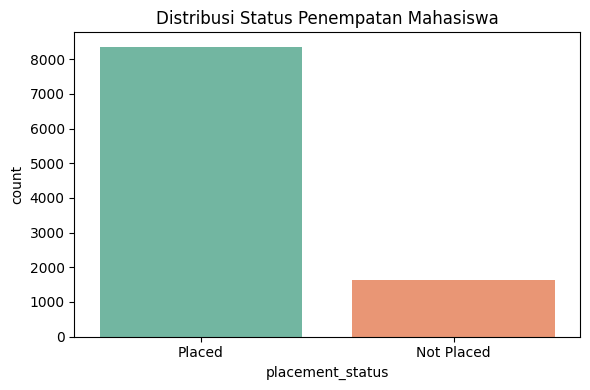

In [5]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

print("\n--- Distribusi Kelas Target Penempatan ---")
print(df['placement_status'].value_counts())

# Visualisasi dan simpan grafik sebaran target
plt.figure(figsize=(6, 4))
sns.countplot(x='placement_status', data=df, palette='Set2')
plt.title('Distribusi Status Penempatan Mahasiswa')
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=300)
plt.show()

## 4. DATA PREPROCESSING
Mengubah variabel target kategorikal teks menjadi angka (0 dan 1) serta memisahkan Fitur ($X$) dan Target ($y$).

In [6]:
# Mengubah teks menjadi angka (Placed = 1, Not Placed = 0)
le = LabelEncoder()
df['placement_status'] = le.fit_transform(df['placement_status'])

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status']

print("Fitur yang digunakan:", X.columns.tolist())
print("Target: placement_status (0 = Not Placed, 1 = Placed)")

Fitur yang digunakan: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']
Target: placement_status (0 = Not Placed, 1 = Placed)


## 5. SPLITTING DATA
Membagi data menjadi data latih (*Training Set*) sebesar 80% dan data uji (*Testing Set*) sebesar 20%.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah data uji (X_test): {X_test.shape[0]}")

Jumlah data latih (X_train): 8000
Jumlah data uji (X_test): 2000


## 6. MODEL TRAINING
Melatih model klasifikasi menggunakan algoritma **Random Forest Classifier**.

In [8]:
# Inisialisasi dan pelatihan model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


## 7. MODEL EVALUATION
Menguji performa model dengan data uji, menampilkan metrik evaluasi, serta menyimpan grafik *Confusion Matrix*.

Akurasi Model: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       329
      Placed       1.00      1.00      1.00      1671

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



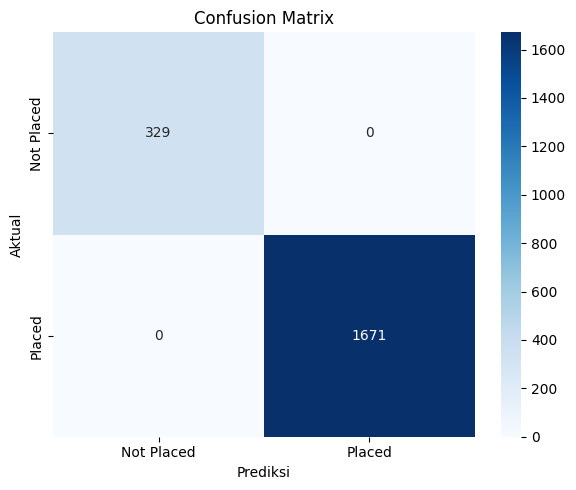

In [9]:
# Prediksi data uji
y_pred = model_rf.predict(X_test)

# Menampilkan akurasi dan laporan klasifikasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Visualisasi dan simpan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=300)
plt.show()

## 8. FEATURE IMPORTANCE
Menganalisis fitur atau faktor apa saja yang paling memengaruhi kelulusan penempatan mahasiswa berdasarkan bobot dari model.

C:\Users\hp\AppData\Local\Temp\ipykernel_28580\827519919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


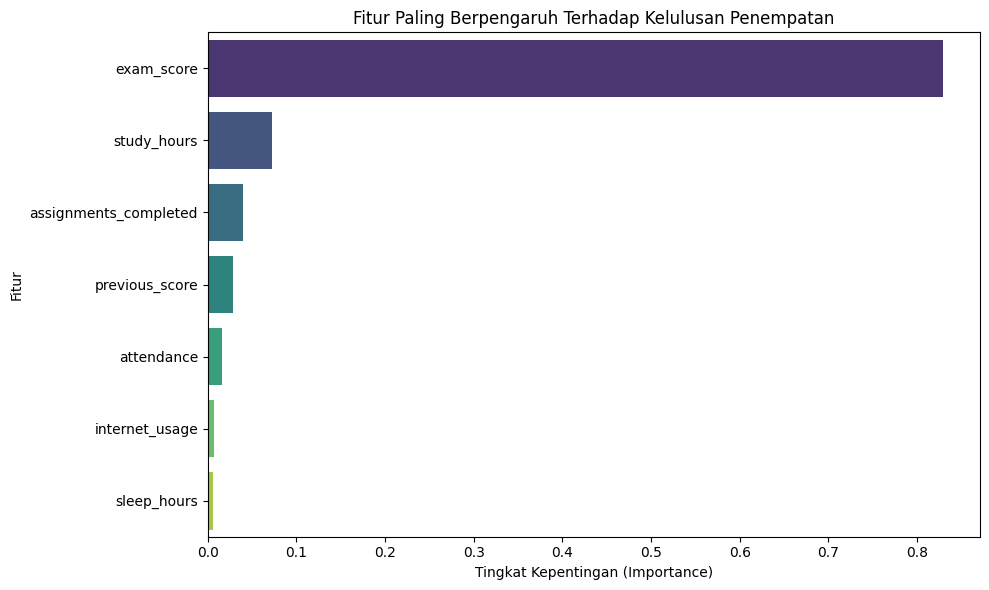

In [10]:
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Visualisasi dan simpan grafik Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Fitur Paling Berpengaruh Terhadap Kelulusan Penempatan')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300)
plt.show()

## 9. EXPORT MODEL
Menyimpan model Random Forest yang telah dilatih ke dalam folder `../models/` agar bisa digunakan kembali di masa mendatang untuk memprediksi data baru tanpa perlu melatih ulang.

In [11]:
# Menyimpan model ke dalam folder models
path_model = '../models/random_forest_model.pkl'
joblib.dump(model_rf, path_model)

print(f"Model berhasil diexport dan disimpan di: {path_model}")

Model berhasil diexport dan disimpan di: ../models/random_forest_model.pkl
